<h1 align="center">All About Positional Encodings</h1>

## 1. Import Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
import warnings

In [13]:
warnings.filterwarnings(action="ignore")

## 2. Positional Encoding Functions

In [14]:
def sinusoidal_pe(seq_len, d_model):
    # Compute sin/cos positional encoding matrix, shape (seq_len, d_model)
    pe = np.zeros((seq_len, d_model))
    positions = np.arange(seq_len).reshape(-1, 1)
    dims = np.arange(0, d_model, 2)
    denominators = 10000 ** (dims / d_model)
    pe[:, 0::2] = np.sin(positions / denominators)
    pe[:, 1::2] = np.cos(positions / denominators)
    return pe

In [15]:
def relative_pe_matrix(seq_len):
    # Entry (i, j) = j - i, normalized to [-1, 1]
    positions = np.arange(seq_len)
    rel = positions[np.newaxis, :] - positions[:, np.newaxis]
    return rel / (seq_len - 1)

In [16]:
def rope_pe(seq_len, d_model):
    # RoPE cosine/sine rotation components interleaved, shape (seq_len, d_model)
    half = d_model // 2
    positions = np.arange(seq_len)
    dims = np.arange(half)
    thetas = 1.0 / (10000 ** (2 * dims / d_model))
    angles = np.outer(positions, thetas)
    pe = np.empty((seq_len, d_model))
    pe[:, 0::2] = np.cos(angles)
    pe[:, 1::2] = np.sin(angles)
    return pe

In [17]:
def alibi_pe(seq_len, d_model):
    # ALiBi penalty averaged across 8 heads, tiled to fill d_model columns
    num_heads = 8
    slopes = 2 ** (-np.arange(1, num_heads + 1) * 8 / num_heads)
    positions = np.arange(seq_len)
    dist = -np.abs(positions[:, np.newaxis] - positions[np.newaxis, :])
    avg_penalty = (slopes[:, np.newaxis, np.newaxis] * dist[np.newaxis]).mean(axis=0)
    avg_penalty = avg_penalty / np.abs(avg_penalty).max()
    cols = np.linspace(0, seq_len - 1, d_model).astype(int)
    return avg_penalty[:, cols]

## 3. Static 2x2 Comparison Plot

In [18]:
seq_len = 50
d_model = 64

pe_sin = sinusoidal_pe(seq_len, d_model)
pe_rel = relative_pe_matrix(seq_len)
pe_rope = rope_pe(seq_len, d_model)
pe_alibi = alibi_pe(seq_len, d_model)

cols = np.linspace(0, seq_len - 1, d_model).astype(int)
pe_rel_tiled = pe_rel[:, cols]

In [19]:
plt.rcParams.update({
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "axes.edgecolor": "#cccccc",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "grid.color": "#eeeeee",
    "text.color": "#333333",
    "axes.titlecolor": "#111111",
})

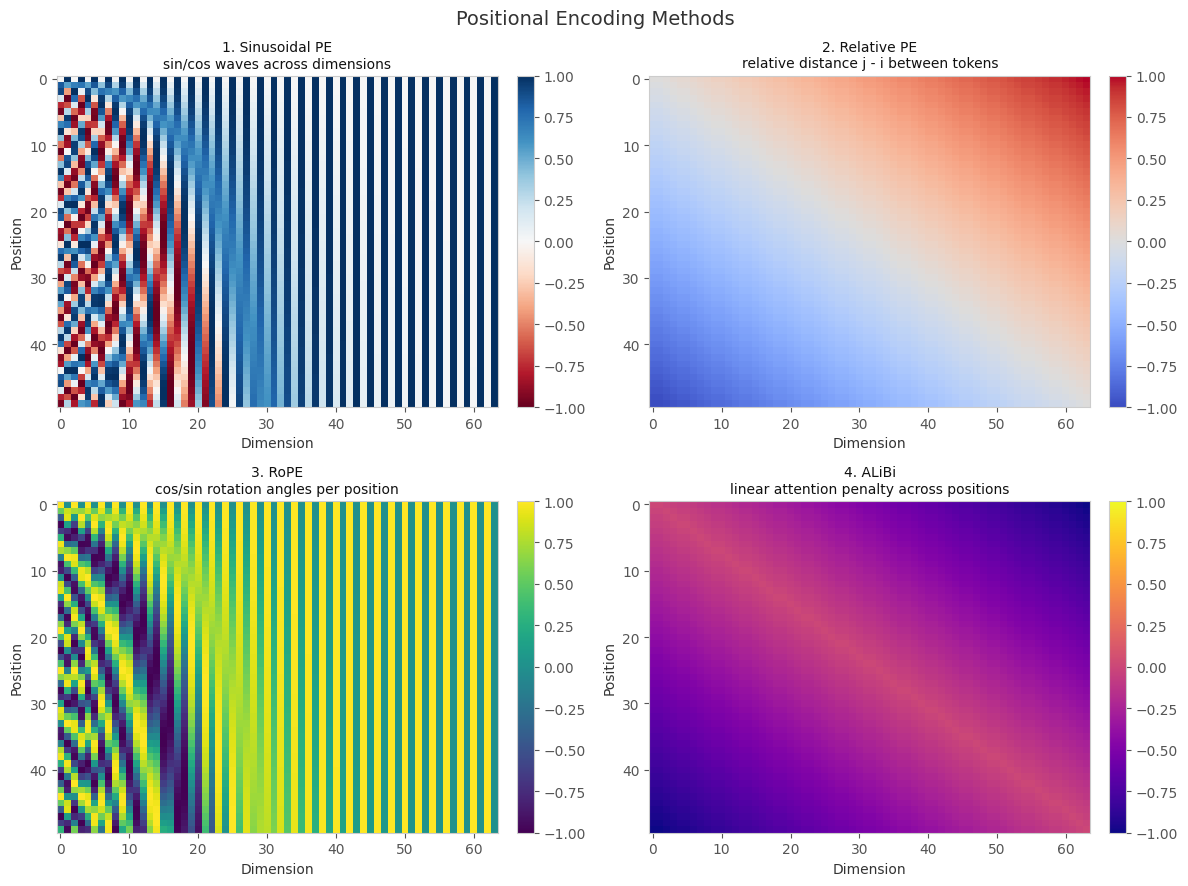

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Positional Encoding Methods", fontsize=14)

configs = [
    (pe_sin, "1. Sinusoidal PE", "RdBu", "sin/cos waves across dimensions"),
    (pe_rel_tiled, "2. Relative PE", "coolwarm", "relative distance j - i between tokens"),
    (pe_rope, "3. RoPE", "viridis", "cos/sin rotation angles per position"),
    (pe_alibi, "4. ALiBi", "plasma", "linear attention penalty across positions"),
]

for ax, (data, title, cmap, subtitle) in zip(axes.flat, configs):
    im = ax.imshow(data, aspect="auto", cmap=cmap, origin="upper", vmin=-1, vmax=1)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("positional_encoding_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

## 4. RoPE Animated GIF: Token Boxes + Rotating Vector

In [21]:
# Layout: unit circle on the left, token boxes along the right side.
# As we step through each token, the corresponding box highlights
# and the vector rotates to its new angle on the circle.

tokens = ["the", "boy", "sat", "on", "the", "mat", "with", "his", "dog"]
num_tokens = len(tokens)
d_model_rope = 32

# Use dimension pair index 2 — not the highest frequency (too fast),
# not the lowest (too slow), gives a nice visible sweep across 9 tokens
dim_pair = 2
theta = 1.0 / (10000 ** (2 * dim_pair / d_model_rope))
angles = theta * np.arange(num_tokens)

# Rotated unit vectors for each token
vx_all = np.cos(angles)
vy_all = np.sin(angles)

# Color per token — warm gradient so progression is obvious
token_colors = plt.cm.plasma(np.linspace(0.15, 0.85, num_tokens))

hold_f = 35
trans_f = 20
total_frames = num_tokens * (hold_f + trans_f)

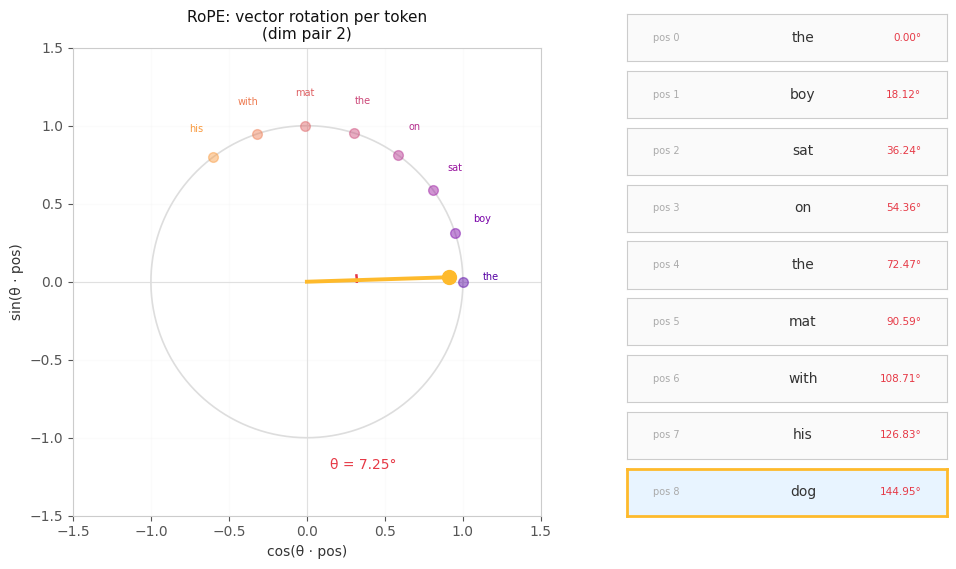

In [22]:
fig = plt.figure(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")

# Left axes: unit circle with rotating vector
ax_circle = fig.add_axes([0.05, 0.12, 0.52, 0.78])
ax_circle.set_facecolor("#ffffff")
ax_circle.set_aspect("equal")
ax_circle.set_xlim(-1.5, 1.5)
ax_circle.set_ylim(-1.5, 1.5)
ax_circle.axhline(0, color="#e0e0e0", linewidth=0.8)
ax_circle.axvline(0, color="#e0e0e0", linewidth=0.8)
ax_circle.grid(True, alpha=0.2)

# Unit circle reference ring
ring_t = np.linspace(0, 2 * np.pi, 300)
ax_circle.plot(np.cos(ring_t), np.sin(ring_t), color="#dddddd", linewidth=1.2)

ax_circle.set_title("RoPE: vector rotation per token\n(dim pair 2)", fontsize=11,
    color="#111111", loc="center")
ax_circle.set_xlabel("cos(θ · pos)")
ax_circle.set_ylabel("sin(θ · pos)")

# Trail dots for all visited token positions
trail_dots = [ax_circle.plot([], [], "o", color=token_colors[i],
    markersize=7, alpha=0.45, zorder=3)[0] for i in range(num_tokens)]

# Small angle labels at each trail dot position (hidden until visited)
trail_labels = [ax_circle.text(0, 0, "", fontsize=7, color=token_colors[i],
    ha="center", va="bottom", zorder=4) for i in range(num_tokens)]

# The active rotating vector drawn as a thick line from origin to tip
vec_line, = ax_circle.plot([], [], "-", color="#0077cc", linewidth=2.8, zorder=5)
vec_dot, = ax_circle.plot([], [], "o", color="#0077cc", markersize=10, zorder=6)

# Angle arc from 0 to current angle
arc_line, = ax_circle.plot([], [], "-", color="#e63946", linewidth=1.8, zorder=4)

# Text showing current angle value
angle_label = ax_circle.text(0.55, 0.1, "", fontsize=10, color="#e63946",
    transform=ax_circle.transAxes, ha="left")

# Right side: token boxes stacked vertically
# Positions in figure coordinates
box_left = 0.63
box_width = 0.32
n = num_tokens
box_height_fig = 0.78 / n
box_gap = 0.008

token_axes = []
for i in range(n):
    # Stack from top to bottom
    bottom = 0.12 + (n - 1 - i) * (box_height_fig + box_gap)
    axt = fig.add_axes([box_left, bottom, box_width, box_height_fig - box_gap])
    axt.set_xlim(0, 1)
    axt.set_ylim(0, 1)
    axt.set_xticks([])
    axt.set_yticks([])
    # Default box style
    for spine in axt.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#cccccc")
    axt.set_facecolor("#f9f9f9")
    # Token index label on the left, word in the center
    axt.text(0.08, 0.5, f"pos {i}", fontsize=7, color="#aaaaaa",
        va="center", ha="left")
    axt.text(0.55, 0.5, tokens[i], fontsize=10, color="#333333",
        va="center", ha="center")
    token_axes.append(axt)

# Angle value text on the right of each token box (filled in as we visit)
angle_texts = [axt.text(0.92, 0.5, "", fontsize=7.5, color="#e63946",
    va="center", ha="right") for axt in token_axes]

plt.tight_layout()


def get_tok_blend(frame):
    # Current token index and blend fraction toward the next token
    cycle = hold_f + trans_f
    tok = (frame // cycle) % num_tokens
    f_in = frame % cycle
    if f_in < hold_f:
        return tok, 0.0
    return tok, (f_in - hold_f) / trans_f


def update(frame):
    tok, blend = get_tok_blend(frame)
    next_tok = (tok + 1) % num_tokens

    # Interpolate vector smoothly between current and next token angle
    vx = (1 - blend) * vx_all[tok] + blend * vx_all[next_tok]
    vy = (1 - blend) * vy_all[tok] + blend * vy_all[next_tok]
    current_angle = (1 - blend) * angles[tok] + blend * angles[next_tok]

    # Update the rotating vector line and tip dot
    vec_line.set_data([0, vx], [0, vy])
    vec_dot.set_data([vx], [vy])
    vec_line.set_color(token_colors[tok])
    vec_dot.set_color(token_colors[tok])

    # Angle arc from 0 to current angle
    arc_t = np.linspace(0, max(current_angle, 1e-4), 80)
    arc_line.set_data(0.32 * np.cos(arc_t), 0.32 * np.sin(arc_t))

    angle_label.set_text(f"θ = {np.degrees(current_angle):.2f}°")

    # Trail: show all previously fully visited token vectors
    for i in range(num_tokens):
        if i < tok:
            trail_dots[i].set_data([vx_all[i]], [vy_all[i]])
            # Label offset slightly outward from the dot
            offset = 1.18
            trail_labels[i].set_position((vx_all[i] * offset, vy_all[i] * offset))
            trail_labels[i].set_text(tokens[i])
        else:
            trail_dots[i].set_data([], [])
            trail_labels[i].set_text("")

    # Token box highlighting
    for i, (axt, atxt) in enumerate(zip(token_axes, angle_texts)):
        if i == tok:
            # Active token: colored border and background
            axt.set_facecolor("#e8f4ff")
            for spine in axt.spines.values():
                spine.set_edgecolor(token_colors[tok])
                spine.set_linewidth(2.0)
            atxt.set_text(f"{np.degrees(angles[i]):.2f}°")
        elif i < tok:
            # Already visited: light tint, show angle
            axt.set_facecolor("#fafafa")
            for spine in axt.spines.values():
                spine.set_edgecolor("#cccccc")
                spine.set_linewidth(0.8)
            atxt.set_text(f"{np.degrees(angles[i]):.2f}°")
        else:
            # Not yet visited: plain
            axt.set_facecolor("#f9f9f9")
            for spine in axt.spines.values():
                spine.set_edgecolor("#cccccc")
                spine.set_linewidth(0.8)
            atxt.set_text("")

    return [vec_line, vec_dot, arc_line, angle_label] + trail_dots + trail_labels

ani = FuncAnimation(fig, update, frames=total_frames, interval=60, blit=False)
ani.save("rope_vector_rotation.gif", writer=PillowWriter(fps=14), dpi=100)
plt.show()